# Habitat Simulator Intro: 3D Navigation & Pathfinding

**Personal Project by Nandan NATESAN**
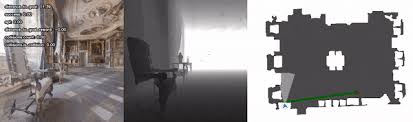


# HabitatSim Setup


In [1]:
!pip install seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 98.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 156.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 46.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 137.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 22.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 95.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [seaborn]


## Setup (Local Machine)
If you're using a local machine, follow the [installation instructions on the HabitatSim Github](https://github.com/facebookresearch/habitat-sim?tab=readme-ov-file#installation). If you have conda, that's typically the quickest way to get things set up.


## Setup (Colab)
HabitatSim actually officially dropped support for Colab quite recently... That doesn't stop us though! Below, we'll download a custom conda build I made so things work.

First we'll install miniconda in Colab


In [2]:
!wget -c https://repo.continuum.io/miniconda/Miniconda3-latest-Linux-x86_64.sh
!bash Miniconda3-latest-Linux-x86_64.sh -bfp /usr/local


--2025-10-30 22:37:59--  https://repo.continuum.io/miniconda/Miniconda3-latest-Linux-x86_64.sh
Resolving repo.continuum.io (repo.continuum.io)... 104.18.176.84, 104.18.177.84, 2606:4700::6812:b154, ...
Connecting to repo.continuum.io (repo.continuum.io)|104.18.176.84|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh [following]
--2025-10-30 22:37:59--  https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.191.158, 104.16.32.241, 2606:4700::6810:bf9e, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.191.158|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.

PREFIX=/usr/local
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... d

Then, we'll download the custom conda build for python 3.12 using gdown


In [3]:
!pip install gdown -q
!gdown "https://drive.google.com/uc?id=1zE7ATGuIlIqQV6pct-w58LhET6CtCIeE"


Downloading...
From (original): https://drive.google.com/uc?id=1zE7ATGuIlIqQV6pct-w58LhET6CtCIeE
From (redirected): https://drive.google.com/uc?id=1zE7ATGuIlIqQV6pct-w58LhET6CtCIeE&confirm=t&uuid=553935fd-2481-426d-95d5-d46fb99efa0a
To: /content/habitat-sim-0.3.3-py3.12_headless_linux_6c26c4f9ae10ad7f534aa9e59a84dff00782741e.conda
100% 192M/192M [00:03<00:00, 55.4MB/s]


In [4]:
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
!conda install habitat-sim-0.3.3-py3.12_headless_linux_6c26c4f9ae10ad7f534aa9e59a84dff00782741e.conda


accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r
Jupyter detected...
2 channel Terms of Service accepted



## Package Plan ##

  environment location: /usr/local





Preparing transaction: - done
Verifying transaction: | done
Executing transaction: - done


Install some other necessary dependencies


In [5]:
!/usr/bin/python3 -m pip install \
  "attrs>=19.1.0" \
  numpy-quaternion \
  gitpython \
  imageio \
  imageio-ffmpeg \
  matplotlib \
  numba \
  pillow==10.4.0 \
  "scipy>=1.10.1" \
  tqdm \
  "numpy==1.26.4"


1. You can **IGNORE** the errors above.
2. But make sure to **RESTART YOUR SESSION.**
3. Continue running from the cell below

Note, that every time you reset the session, just run the cell below.


In [6]:
import sys
sys.path.append('/usr/local/lib/python3.12/site-packages')


# Download the Data
To view a full list of the datasets available for download checkout [this readme](https://github.com/facebookresearch/habitat-lab/blob/main/DATASETS.md).

To get access to the download scipt to several of these datasets (ex. all MP3D scans), you have to fill out an agreement and send in your responses via email which can take a while: [Matterport3D](https://niessner.github.io/Matterport/).

For this lab, we'll just be using the *habitat_test_scenes*.


In [ ]:
# The following should work if you're not using colab
!python -m habitat_sim.utils.datasets_download --uids habitat_test_scenes --data-path data/


In [7]:
# In colab, try this
import habitat_sim.utils.datasets_download as dd
dd.main(["--uids", "habitat_test_scenes", "--data-path", "data/"])


git clone --depth 1 --branch main https://huggingface.co/datasets/ai-habitat/habitat_test_scenes.git /content/data/versioned_data/habitat_test_scenes
Dataset (habitat_test_scenes) successfully downloaded.
Source: '/content/data/versioned_data/habitat_test_scenes'
Symlink: '/content/data/scene_datasets/habitat-test-scenes'


# An Introduction to Habitat
As a recap from last lab there's two main components to Habitat:
1. [HabitatSim](https://github.com/facebookresearch/habitat-sim): a flexible, high performance 3D simulator defining configurable agents, multiple sensors, high throughput rendering, and generic 3D dataset handling.
2. [HabitatLab](https://github.com/facebookresearch/habitat-lab): a modular high-level library for end-to-end development for embodied AI tasks.

Additionally, there are also [Habitat Challenges](https://aihabitat.org/challenge/2023/) for specific tasks (i.e. PointGoal Navigation, Rearrangement, etc).


Today, we'll mainly be focusing on **HabitatSim**. The basic workflow of HabitatSim for navigation is the following:
- config and start the simulator
- load a scene
- setup an agent with a sensor
- instruct the agent to move somehow
- obtain the observations.


# Setting Up Your First Environment with HabitatSim

Now, we'll set up our first envirionment! This involves three main steps:
1. Configure the sensors
2. Configure the agent
3. Configure the simulator backend / scene


In [8]:
import random

from PIL import Image

%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np

import habitat_sim

# Plotting
import seaborn as sns
import matplotlib
matplotlib.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")


### Sensor Configuration
First, we'll configure the sensors. In this environment we'll set up an RGB "color_sensor" and depth depth sensor.

You can customize many properties of the sensors, such as spatial resolution, position, rotation, etc.


In [9]:
sensor_settings = {
    "height": 256, "width": 256,  # Spatial resolution of observations
    "sensor_height": 1.5,  # Height of sensors in meters, relative to the agent
}

# Create a RGB sensor configuration
rgb_sensor_spec = habitat_sim.CameraSensorSpec()
rgb_sensor_spec.uuid = "color_sensor"
rgb_sensor_spec.sensor_type = habitat_sim.SensorType.COLOR
rgb_sensor_spec.resolution = [sensor_settings["height"], sensor_settings["width"]]
rgb_sensor_spec.position = [0.0, sensor_settings["sensor_height"], 0.0]
rgb_sensor_spec.sensor_subtype = habitat_sim.SensorSubType.PINHOLE

# Create a depth sensor configuration
depth_sensor_spec = habitat_sim.CameraSensorSpec()
depth_sensor_spec.uuid = "depth_sensor"
depth_sensor_spec.sensor_type = habitat_sim.SensorType.DEPTH
depth_sensor_spec.resolution = [sensor_settings["height"], sensor_settings["width"]]
depth_sensor_spec.position = [0.0, sensor_settings["sensor_height"], 0.0]
depth_sensor_spec.sensor_subtype = habitat_sim.SensorSubType.PINHOLE

sensor_specs = [rgb_sensor_spec, depth_sensor_spec]

print(sensor_specs)


[<habitat_sim._ext.habitat_sim_bindings.CameraSensorSpec object at 0x7babc8db9d30>, <habitat_sim._ext.habitat_sim_bindings.CameraSensorSpec object at 0x7babc8c0ca10>]


### Agent Configuration

Next, we'll set up the configuration for the agent in the simulator.

Here, we specify the action space of the agent:
- the distance to move forward during a move action
- the angle magnitudes to turn during a turn action

Note that the agent configuration also contains all of the sensor configurations. This is because the sensors are rigidly attached to the agent, and renderning will be affected based on how the agent moves.


In [10]:
agent_settings = {
    "action_space": {
        "move_forward": 0.25, "move_backward": 0.25,  # Distance to cover in a move action in meters
        "turn_left": 30.0, "turn_right": 30,  # Angles to cover in a turn action in degrees
    }
}

# Create an agent configuration
agent_cfg = habitat_sim.agent.AgentConfiguration()
agent_cfg.action_space = {
    k: habitat_sim.agent.ActionSpec(
        k, habitat_sim.agent.ActuationSpec(amount=v)
    ) for k, v in agent_settings["action_space"].items()
}
agent_cfg.sensor_specifications = sensor_specs


### Simulator Configuration
Finally, we'll set up the configuration for the simulator backend. This includes specifying which scene file we'll use, whether to enable physics, and which device to use for rendering.


In [11]:
sim_settings = {
    "default_agent": 0,  # Index of the default agent
    "scene_id": "data/scene_datasets/habitat-test-scenes/apartment_1.glb",  # Scene file, episode 0 in val split of Gibson
    "enable_physics": False,  # kinematics only
    "seed": 42  # used in the random navigation
}

# Create a simulator backend configuration
sim_cfg = habitat_sim.SimulatorConfiguration()
sim_cfg.scene_id = sim_settings["scene_id"]
sim_cfg.enable_physics = sim_settings["enable_physics"]
sim_cfg.gpu_device_id = -1 # CPU rendering


Now we'll use the configurations we just made to make a *master* configuration object for the whole simulation.


In [12]:
# Create a configuration for the simulator
cfg = habitat_sim.Configuration(sim_cfg, [agent_cfg])


### Create a Simulator Instance
Use the master configuration to make the simulator!


In [13]:
try:
    sim.close()
except NameError:
    pass
sim = habitat_sim.Simulator(cfg)
agent = sim.initialize_agent(sim_settings["default_agent"])  # Get our default agent



# Manual Navigation
Now that you have set up the simulator, you can take manual discrete actions and render the sensor outputs at each simulation step!


In [14]:
# Set the random seed for funsies
random.seed(sim_settings["seed"])
sim.seed(sim_settings["seed"])


First, we'll set up this utility function used for rendering the RGB + D information to the screen


In [15]:
# A utility function for displaying observations
def display_obs(rgb_obs: np.ndarray, depth_obs: np.ndarray):
    img_arr, title_arr = [], []

    rgb_img = Image.fromarray(rgb_obs, mode="RGBA")
    img_arr.append(rgb_img)
    title_arr.append("rgb")

    depth_img = Image.fromarray((depth_obs / 10 * 255).astype(np.uint8), mode="L")
    img_arr.append(depth_img)
    title_arr.append("depth")

    plt.figure(figsize=(12, 8))
    for i, (img, title) in enumerate(zip(img_arr, title_arr)):
        ax = plt.subplot(1, 2, i + 1)
        ax.axis("off")
        ax.set_title(title)
        plt.imshow(img)
    plt.show(block=False)


Now, we'll hardcode the agen't position to something reasonable.


In [16]:
# Set agent state
agent_state = habitat_sim.AgentState()
agent_state.position = np.array([0.0, -1.51, -0.6])  # Position in world coordinate
agent_state.rotation = np.array([0, 0, 0, 1])  # Orientation quaternion wrt world frame (identity)
agent.set_state(agent_state)

# Get agent state
agent_state = agent.get_state()
print(f"Agent state: position ({agent_state.position}), rotation ({agent_state.rotation})")


Agent state: position ([ 0.   -1.51 -0.6 ]), rotation (quaternion(1, 0, 0, 0))


Now, you can step through the environment manually using your keyboard. You can specify one of the four discrete actions (`move_forward`, `turn_left`, `move_backward`, `turn_right`) by pressing (`W`, `A`, `S`, `D`) respectively.

Retrieve observations from the simulator and render them using `display_obs()`.


Use WASD to control the agent now (Q to quit): wwwwwwwaaaaaaaaaaaassssdddddddddQ
Invalid input WWWWWWWAAAAAAAAAAAASSSSDDDDDDDDDQ. Please only use WASD!
Use WASD to control the agent now (Q to quit): WASDQ
Invalid input WASDQ. Please only use WASD!
Use WASD to control the agent now (Q to quit): WWWWWWQ
Invalid input WWWWWWQ. Please only use WASD!
Use WASD to control the agent now (Q to quit): WWWW
Invalid input WWWW. Please only use WASD!
Use WASD to control the agent now (Q to quit): WASD
Invalid input WASD. Please only use WASD!
Use WASD to control the agent now (Q to quit): W
Choose to move_forward


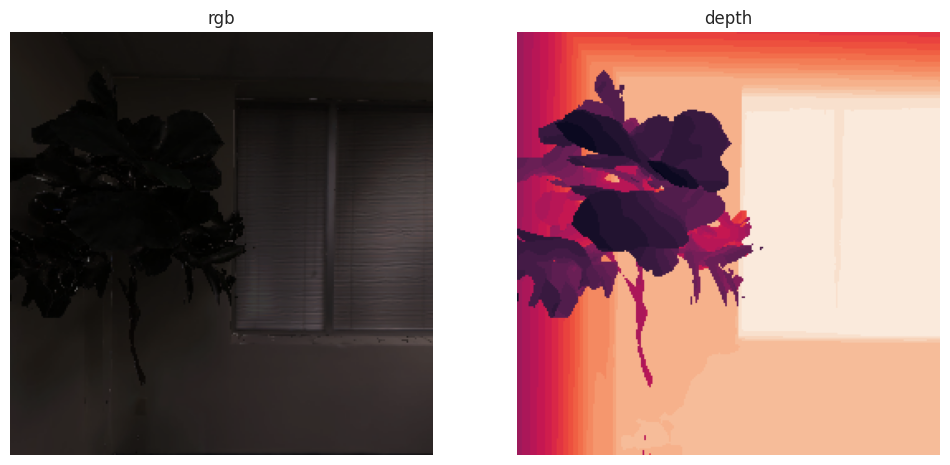

Use WASD to control the agent now (Q to quit): W
Choose to move_forward


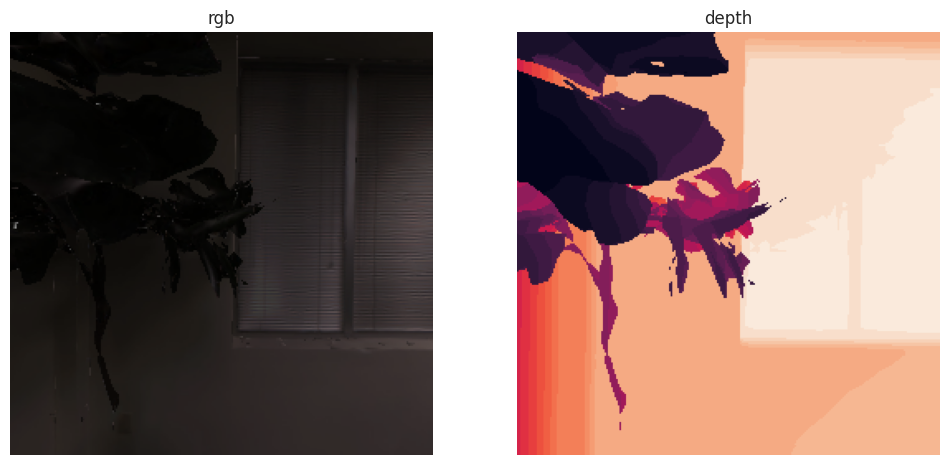

Use WASD to control the agent now (Q to quit): D
Choose to turn_right


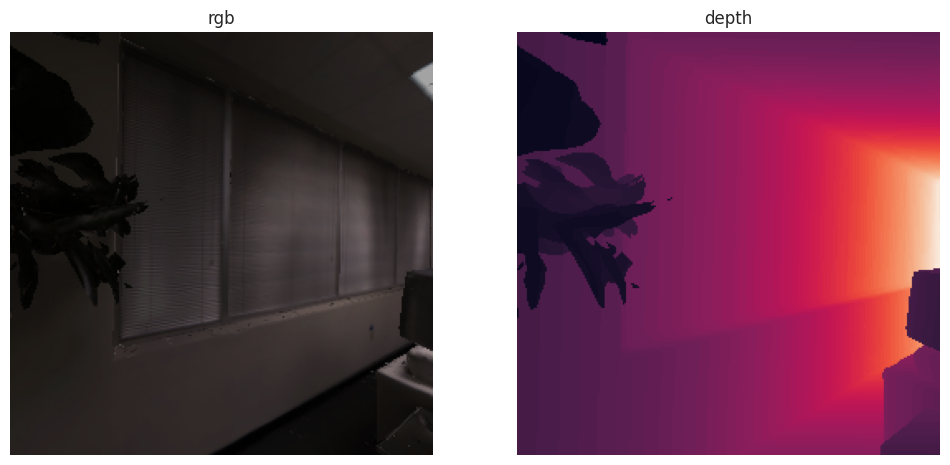

Use WASD to control the agent now (Q to quit): D
Choose to turn_right


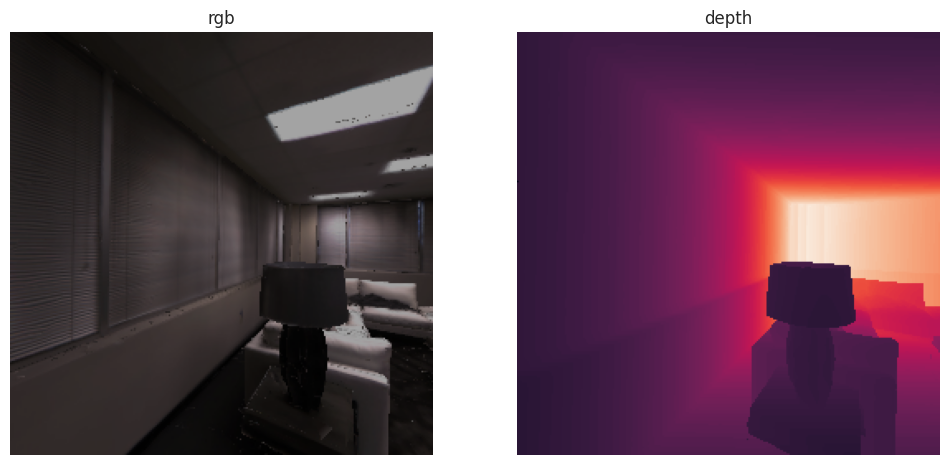

Use WASD to control the agent now (Q to quit): D
Choose to turn_right


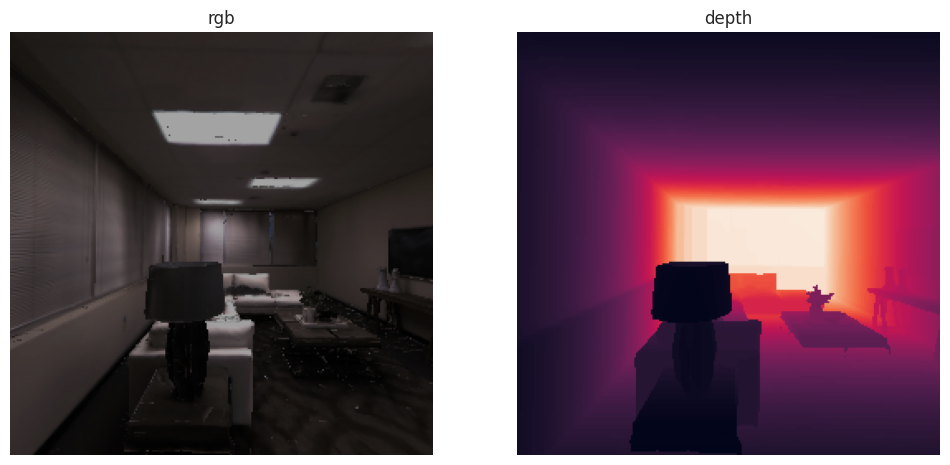

Use WASD to control the agent now (Q to quit): D
Choose to turn_right


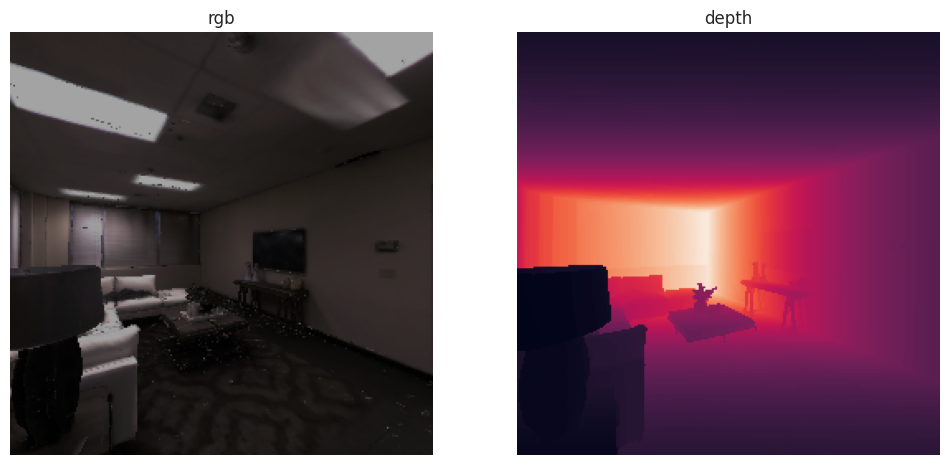

Use WASD to control the agent now (Q to quit): W
Choose to move_forward


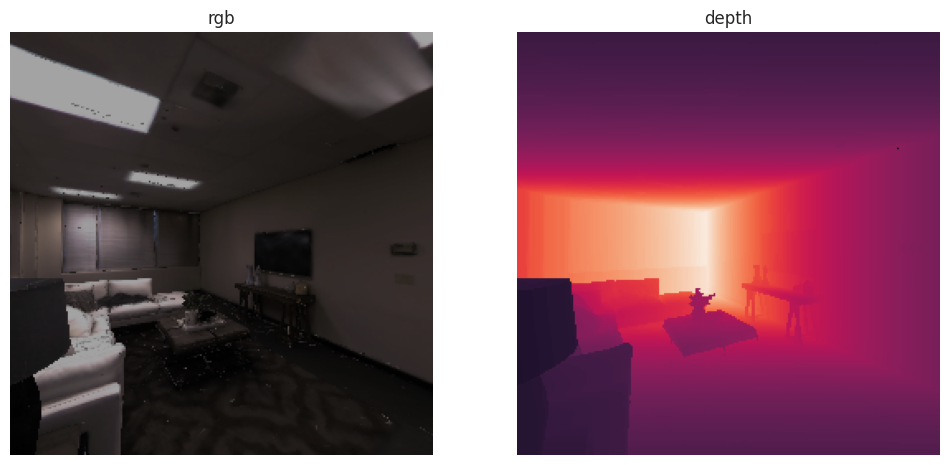

Use WASD to control the agent now (Q to quit): W
Choose to move_forward


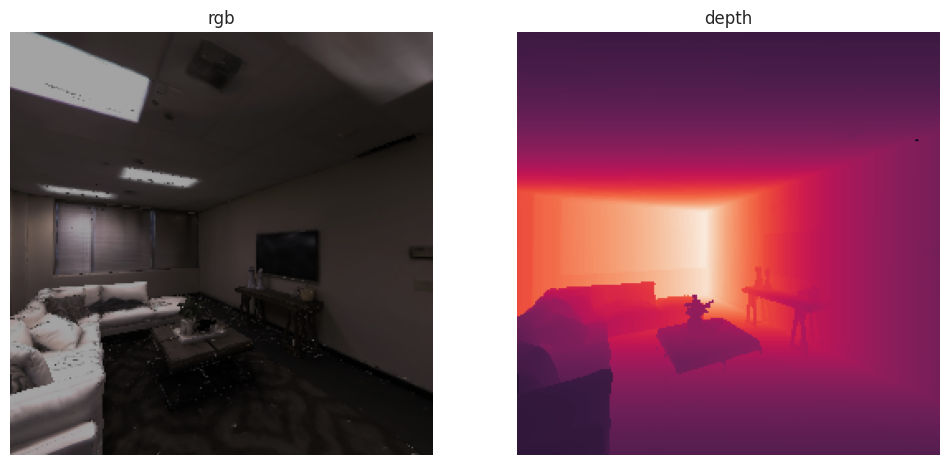

Use WASD to control the agent now (Q to quit): W
Choose to move_forward


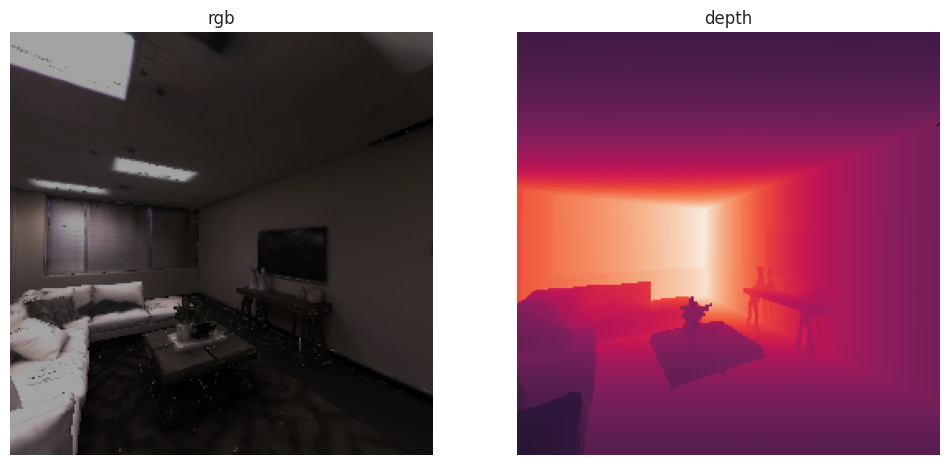

Use WASD to control the agent now (Q to quit): W
Choose to move_forward


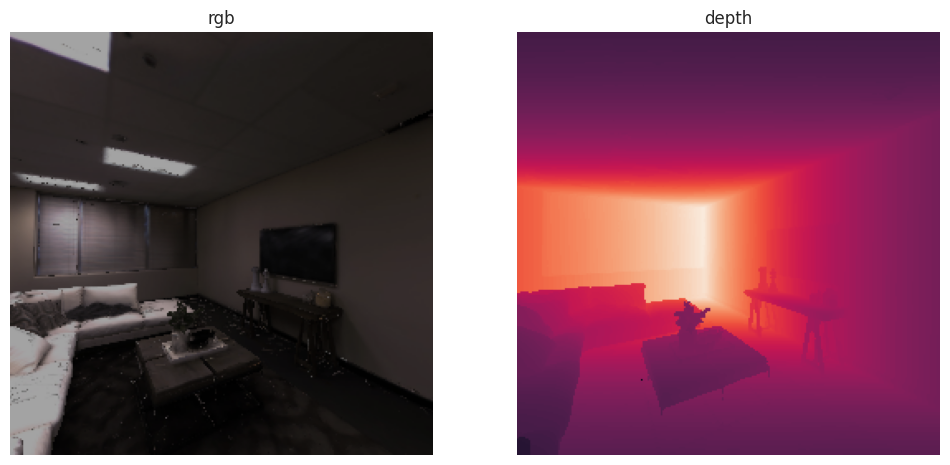

Use WASD to control the agent now (Q to quit): Q
Bye...


In [17]:
import time
key_bindings = {
    'W': 'move_forward',
    'A': 'turn_left',
    'S': 'move_backward',
    'D': 'turn_right',
}
while True:
    time.sleep(0.5) # Needed in COLAB becuase it's silly when running a plt.show() and input() next to each other
    key_pressed = input('Use WASD to control the agent now (Q to quit): ')
    key_pressed = key_pressed.upper()
    if key_pressed == 'Q':
        print("Bye...")
        break
    elif key_pressed in key_bindings.keys():
        action = key_bindings[key_pressed]
        print(f"Choose to {action}")

        obs = sim.step(action)
        display_obs(obs["color_sensor"], obs["depth_sensor"])

    else:
        print(f"Invalid input {key_pressed}. Please only use WASD!")


# The NavMesh

In the previous section, we took the implementation of the agent's "interaction" with its environment for granted (i.e. collisions, navigation contraints, etc). By default, these are enabled in the discrete HabitatSim action space. However, if we naiively updated the agent state (its position and orientation) it wouldn't sense the boundary of the scenes or obstacles when taking its actions.

To enable these constraints during navigation, HabitatSim uses a lightweight and fast "NavMesh" representation, by integrating a poopular Navmesh generation library [Recast Navigation | Detour](https://github.com/recastnavigation/recastnavigation) through the [nav module](https://aihabitat.org/docs/habitat-sim/habitat_sim.nav.html).


### What is a NavMesh?
A navigation mesh (NavMesh) is a collection of two-dimensional convex polygons (i.e., a polygon mesh) that define which areas of an environment are traversable by an agent with a particular embodiment. This representation prevents the agent from freely navigating around areas in the scene that contain large objects, walls, gaps, or other barriers.

The NavMesh (an example shown in the image below) is computed by voxelizing the static scene and generating polygons on the top surfaces of solid voxels where the agent (approximated as a cyllinder) would sit without intersection or overhanging and respecting configured constraints such as maximum climbable slope and step-height.

<div>
<img src="https://github.com/recastnavigation/recastnavigation/raw/main/Docs/Images/screenshot.png" width="600"/>
</div>


### Visualizing the NavMesh
The NavMesh is a 3D mesh, but the [PathFinder API](https://aihabitat.org/docs/habitat-sim/habitat_sim.nav.PathFinder.html) makes it easy to produce a topdown map of navigatability in the scene. However, many of the scenes we'll work with have multiple floors, so we'll need to slice the NavMesh at specific world height. A top-down map can then be created by sampling the NavMesh at configurable resolution (`meter_per_pixel`) with 0.5 m of verticle sampling height.


The NavMesh bounds are: (Vector(-0.960305, -1.80025, -2.59948), Vector(6.94256, 2.7438, 8.14176))


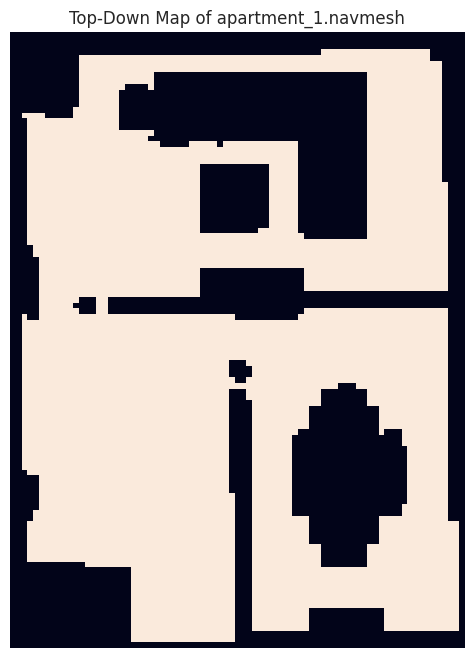

In [18]:
# display a topdown map with matplotlib
def display_map(topdown_map, key_points=None):
    plt.figure(figsize=(12, 8))
    plt.title("Top-Down Map of apartment_1.navmesh")
    ax = plt.subplot(1, 1, 1)
    ax.axis("off")
    plt.imshow(topdown_map)


# Configure example params
meters_per_pixel = 0.1
custom_height = False
height = 1

print("The NavMesh bounds are: " + str(sim.pathfinder.get_bounds()))
if not custom_height:
    # get bounding box minimum elevation for automatic height
    height = sim.pathfinder.get_bounds()[0][1]


sim_topdown_map = sim.pathfinder.get_topdown_view(meters_per_pixel, height)
display_map(sim_topdown_map)


Describe the world coordinate frame with respect to the image above. In other words, what directions are world x, world y, and world z.

World Y-axis (Up/Down): This axis is pointing out of the image, perpendicular to the map. The map itself is a 2D slice at a specific height (height = -1.80025) along this axis.

World X-axis (Left/Right): This axis corresponds to the horizontal direction of the image (the columns). Increasing X goes to the right.

World Z-axis (Forward/Back): This axis corresponds to the vertical direction of the image (the rows). Increasing Z goes down the image.


### Using the NavMesh
The navmesh can be used to very quickly determine which locations are "navigatable" and can also compute valid paths between different locations in the scene.

 Use the [habitat_sim](https://aihabitat.org/docs/habitat-sim/habitat_sim.nav.html) documentation to fill out the below code block to find an optimal path between a randomly sampled start and end point


In [19]:
import magnum as mn
import numpy as np

seed = 6
sim.pathfinder.seed(seed)

sample1 = sim.pathfinder.get_random_navigable_point()
sample2 = sim.pathfinder.get_random_navigable_point()

print("Start position", sample1)
print("End position", sample2)



path = habitat_sim.nav.ShortestPath()
path.requested_start = sample1
path.requested_end = sample2
found_path = sim.pathfinder.find_path(path)
geodesic_distance = path.geodesic_distance
path_points = path.points

# print the output
print("found_path : " + str(found_path))
print("geodesic_distance : " + str(geodesic_distance))
print(f"path_points (size={len(path_points)}): " + str(path_points))


Start position Vector(6.06313, -1.60025, 4.05707)
End position Vector(6.20601, -1.60025, 1.79848)
found_path : True
geodesic_distance : 11.973868370056152
path_points (size=10): [Vector(6.06313, -1.60025, 4.05707), Vector(5.2397, -1.60025, 3.55052), Vector(4.8397, -1.60025, 3.45052), Vector(2.9897, -1.40025, 3.45052), Vector(0.689695, -1.60025, 2.30052), Vector(0.639695, -1.40025, 2.15052), Vector(0.739695, -1.60025, 1.90052), Vector(2.3897, -1.60025, 1.45052), Vector(4.0897, -1.60025, 1.40052), Vector(6.20601, -1.60025, 1.79848)]


### Visualizing the Shortest Path
Now that you have a path from two randomly sampled locations on the navmesh, let's visualize it!

Implement the functions below to render a computed path in the navmesh projection map.


In [20]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon

def world_to_grid(world_points, bounds, meters_per_pixel, H, W):
    """
    Convert world points (px, py, pz) to image (row, col) for a map built with get_topdown_view.
    """
    px = world_points[:, 0]
    pz = world_points[:, 2]

    # Get the origin (top-left corner) of the map in world coordinates
    # bounds[0] is the minimum corner (min_x, min_y, min_z)
    origin_x = bounds[0][0]
    origin_z = bounds[0][2]

    # Calculate column (based on x) and row (based on z)
    col = (px - origin_x) / meters_per_pixel
    row = (pz - origin_z) / meters_per_pixel

    # Cast to int for pixel coordinates
    row = row.astype(int)
    col = col.astype(int)

    # clip to map
    row = np.clip(row, 0, H - 1)
    col = np.clip(col, 0, W - 1)
    return row, col  # (row, col)

def draw_path_on_axes(ax, traj_grid, linewidth=2, color="black", label="geodesic distance"):
    if len(traj_grid) < 2:
        return
    rows = [rc[0] for rc in traj_grid]
    cols = [rc[1] for rc in traj_grid]
    ax.scatter(cols, rows, color=color)
    ax.plot(cols, rows, linewidth=linewidth, linestyle="--", color=color, label=label)

def draw_poly_on_axes(ax, center_rc, heading_rad, agent_radius_px=8, vertices=3, color="black", label="agent"):
    """
    Draw a small marker
    """
    r, c = center_rc
    triangle = RegularPolygon(
        (c, r),
        numVertices=vertices,
        radius=agent_radius_px,
        orientation=heading_rad,
        edgecolor=color,
        facecolor=color,
        linewidth=1.5,
        alpha=0.95,
        label=label
    )
    ax.add_patch(triangle)

# ---------- main helper ----------
def show_topdown_with_path(
    top_down_map,
    scene_bounds,
    path_points,                 # list of world points (x, y, z)
    meters_per_pixel=0.1,
    agent_radius_px=8,
    recolor_map=((0,0,0),(255,255,255)),  # (obstacle, navigable)
    title="navmesh"
):
    H, W = top_down_map.shape

    # Recolor to RGB
    obstacle_rgb = np.array(recolor_map[0], dtype=np.uint8)
    navigable_rgb = np.array(recolor_map[1], dtype=np.uint8)
    topdown_rgb = np.zeros((H, W, 3), dtype=np.uint8)
    topdown_rgb[~top_down_map] = obstacle_rgb
    topdown_rgb[top_down_map]  = navigable_rgb

    # Convert world (x,z) -> grid (row,col)
    traj_grid = []
    # and store in traj_grid
    if not path_points:
        pass # traj_grid is already [], so nothing to do
    else:
        # Convert list of habitat_sim.Vector to (N, 3) numpy array
        path_points_np = np.array([list(pt) for pt in path_points])

        # Convert all points from world to grid
        rows, cols = world_to_grid(path_points_np, scene_bounds, meters_per_pixel, H, W)

        # Store as list of (row, col) tuples
        traj_grid = list(zip(rows, cols))

    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.axis("off")
    ax.imshow(topdown_rgb)
    draw_path_on_axes(ax, traj_grid, linewidth=2.5, color="red", label="path")
    if len(traj_grid) > 0:
        draw_poly_on_axes(ax, traj_grid[0], 0, agent_radius_px=agent_radius_px, color="green", vertices=3, label="agent start") # agent starter position
        draw_poly_on_axes(ax, traj_grid[-1], 0, agent_radius_px=agent_radius_px, color="red", vertices=8, label="agent end") # agent final position

    plt.legend()
    plt.title(title)
    plt.show(block=False)

    return topdown_rgb, traj_grid



Render the top-dopwn map with the shortest path rendered on top of it.


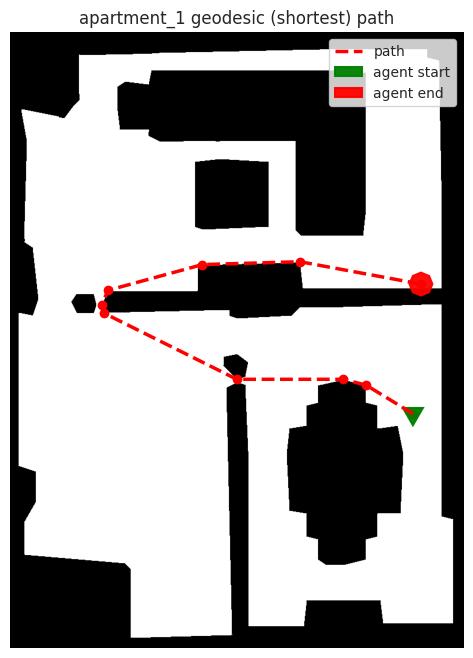

In [21]:
meters_per_pixel = 0.01
height = sim.pathfinder.get_bounds()[0][1]

top_down_map = sim.pathfinder.get_topdown_view(meters_per_pixel, height)
bounds = sim.pathfinder.get_bounds()

rgb_map, traj_grid = show_topdown_with_path(top_down_map, bounds, path_points, meters_per_pixel, agent_radius_px=0.2/meters_per_pixel, title="apartment_1 geodesic (shortest) path")



### Take observations along the shortest path

 Now, given that we have the shortest path, take observations along the path. Update the agent's position so that it follows the path. The agent should take short steps (< 20cm) increments and should always be oriented towards the next waypoint.

I recommend doing the following:
1. Update the path to make a more *discritized* path
2. Loop through the new discritized path, updating the position and orientation of the agent and taking observartions.


In [22]:
import magnum as mn
from habitat_sim.utils import common as utils


# 1. agent.set_state(), as above
# 2. mn.Matrix4.look_at (https://doc.magnum.graphics/python/magnum/Matrix4/#look_at)
# 3. mn.Quaternion.from_matrix (https://doc.magnum.graphics/python/magnum/Quaternion/#from_matrix)
# 4. utils.quat_from_magnum() to convert quaternion conventions from magnum to what agent_state expects.

new_path_points = []
step_size = 0.1  # 10cm increments, which is < 20cm

if path_points and len(path_points) > 1:
    # Add the first point
    new_path_points.append(path_points[0])

    # Iterate over pairs of waypoints
    for i in range(len(path_points) - 1):
        ptA = path_points[i]
        ptB = path_points[i+1]

        # Calculate the vector and distance between points
        vec = ptB - ptA
        dist = vec.length()

        # Determine the number of steps needed
        num_steps = int(np.ceil(dist / step_size))

        if num_steps > 1:
            # Interpolate points between ptA and ptB
            for n in range(1, num_steps):
                interp_pt = ptA + vec * (n / float(num_steps))
                new_path_points.append(interp_pt)

        # Add the end point of the segment
        new_path_points.append(ptB)

    # De-duplicate points that might be too close
    final_path = []
    if new_path_points:
        final_path.append(new_path_points[0])
        for pt in new_path_points[1:]:
            # Only add if the point is measurably different from the last
            if (pt - final_path[-1]).length() > 1e-5:
                final_path.append(pt)
    new_path_points = final_path

print(f"Original path size: {len(path_points)}, Discretized path size: {len(new_path_points)}")


observations_list = []
agent_state = habitat_sim.AgentState()
world_up = mn.Vector3.y_axis() # (0, 1, 0)

if len(new_path_points) > 1:
    # Loop up to the second-to-last point
    for i in range(len(new_path_points) - 1):
        current_pos = new_path_points[i]
        target_pos = new_path_points[i+1]

        # 1. Set agent position
        agent_state.position = current_pos

        # 2. Calculate agent rotation (to look at target)
        # mn.Matrix4.look_at returns a view matrix (world-to-local)
        view_matrix = mn.Matrix4.look_at(current_pos, target_pos, world_up)
        # We need the model matrix (local-to-world), so we invert it
        model_matrix = view_matrix.inverted()

        # 3. Convert the rotation part of the matrix to a quaternion
        rotation_quat_magnum = mn.Quaternion.from_matrix(model_matrix.rotation())

        # 4. Convert from Magnum's quaternion to Habitat's (utils.quat_from_magnum)
        agent_state.rotation = utils.quat_from_magnum(rotation_quat_magnum)

        # 5. Set the agent's state in the simulator
        agent.set_state(agent_state)

        # 6. Get sensor observations from this new state
        obs = sim.get_sensor_observations()
        observations_list.append(obs)

        # You can uncomment the line below to visualize the path traversal
        # display_obs(obs["color_sensor"], obs["depth_sensor"])

    # Set the agent to the final position (using the last orientation)
    agent_state.position = new_path_points[-1]
    agent.set_state(agent_state)
    obs = sim.get_sensor_observations()
    observations_list.append(obs)

print(f"Collected {len(observations_list)} observations along the discretized path.")


Original path size: 10, Discretized path size: 126
Collected 126 observations along the discretized path.


### Construct a Greedy Trajectory Following Agent
Often times, the agent's action space prohibits it from following the shortest path perfectly. This is especially apparent when the agent uses discrete actions (i.e. `turn_left`, `move_forward`) like in our case.

Thankfully, HabitatSim actually implements this trajectory following agent in the [GreedyGeodesicFollower Class](https://aihabitat.org/docs/habitat-sim/habitat_sim.nav.GreedyGeodesicFollower.html) in the nav module.

 Use the GreedyGeodesicFollower to find an action sequence that takes the agent from the start_pos to the goal_pos. The agent should terminate if it gets within 0.15m of the goal.


In [26]:
from habitat_sim.nav import GreedyGeodesicFollower
start_pos = sample1
goal_pos = sample2

# 1. Initialize the GreedyGeodesicFollower
# We pass the pathfinder, the agent, and the specified goal_radius
follower = GreedyGeodesicFollower(sim.pathfinder, agent, goal_radius=0.15)

# 2. Set the agent's state to the start position.
# find_path() calculates the path from the agent's *current* state.
agent_state = agent.get_state()
agent_state.position = start_pos
agent_state.rotation = np.array([0, 0, 0, 1]) # Use a default identity rotation
agent.set_state(agent_state)

# 3. Call find_path() with the goal position.
# This method computes and returns the entire action sequence.
action_sequence = follower.find_path(goal_pos)

print("Greedy follower action sequence:")
print(action_sequence)


Greedy follower action sequence:
['turn_left', 'turn_left', 'move_forward', 'move_forward', 'move_forward', 'move_forward', 'move_forward', 'turn_left', 'move_forward', 'move_forward', 'move_forward', 'move_forward', 'move_forward', 'move_forward', 'move_forward', 'move_forward', 'turn_right', 'move_forward', 'move_forward', 'move_forward', 'move_forward', 'move_forward', 'move_forward', 'move_forward', 'move_forward', 'turn_left', 'move_forward', 'turn_right', 'move_forward', 'move_forward', 'turn_right', 'turn_right', 'turn_right', 'move_forward', 'turn_right', 'move_forward', 'move_forward', 'move_forward', 'turn_right', 'move_forward', 'move_forward', 'move_forward', 'turn_left', 'move_forward', 'turn_right', 'move_forward', 'turn_left', 'move_forward', 'turn_right', 'move_forward', 'move_forward', 'move_forward', 'move_forward', 'move_forward', 'move_forward', 'move_forward', 'move_forward', 'turn_right', 'move_forward', 'move_forward', 'turn_left', 'move_forward', 'move_forward',

Rollout the action sequence produced by the GreedyGeodesicFollower. Then plot its trajectory on the map using `show_topdown_with_path`.


In [27]:

# Reset the agent to the start position before rolling out
agent_state = agent.get_state()
agent_state.position = start_pos # 'start_pos' is 'sample1' from previous cell
agent_state.rotation = np.array([0, 0, 0, 1])
agent.set_state(agent_state)

# Store the agent's path as it takes actions
greedy_path_points = []
greedy_path_points.append(start_pos) # Add the starting point

print("Rolling out greedy action sequence...")
for action in action_sequence:
    if action is None:
        # The 'None' action signifies STOP
        print("...Stop action received.")
        break

    # Take the action in the simulator
    sim.step(action)

    # Get the new state and store the position
    current_state = agent.get_state()
    greedy_path_points.append(current_state.position)

print(f"Rollout complete. Path has {len(greedy_path_points)} points.")


Rolling out greedy action sequence...
...Stop action received.
Rollout complete. Path has 67 points.


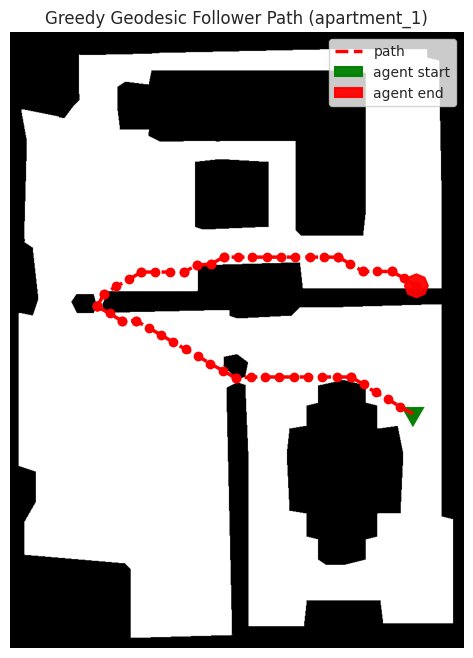

In [28]:

# We need the same map parameters as the previous plot for a good comparison
meters_per_pixel = 0.01
height = sim.pathfinder.get_bounds()[0][1]

# Get the map and bounds
top_down_map = sim.pathfinder.get_topdown_view(meters_per_pixel, height)
bounds = sim.pathfinder.get_bounds()

# Plot the path
rgb_map_greedy, traj_grid_greedy = show_topdown_with_path(
    top_down_map,
    bounds,
    greedy_path_points,  # This is the list of positions from the rollout
    meters_per_pixel,
    agent_radius_px=0.2/meters_per_pixel,
    title="Greedy Geodesic Follower Path (apartment_1)"
)


### Compute the SPL of the GreedyPathFollower
 Compute the SPL!


In [30]:

import numpy as np

# 1. Check for success
# Get the agent's final position (which is a numpy array)
final_pos = greedy_path_points[-1]
# Convert goal_pos (a Vector) to a numpy array for subtraction
goal_pos_np = np.array(goal_pos)
# Calculate distance using numpy's linalg.norm()
final_goal_distance = np.linalg.norm(final_pos - goal_pos_np)
# Check if this distance is within the success radius
success = 1 if final_goal_distance < 0.15 else 0

# 2. Get optimal path length (L)
# This was computed in the "Using the NavMesh" section
path_length_L = geodesic_distance

# 3. Calculate actual path length (P)
path_length_P = 0.0
if len(greedy_path_points) > 1:
    for i in range(len(greedy_path_points) - 1):
        # Convert both points to numpy arrays to be safe
        ptA = np.array(greedy_path_points[i])
        ptB = np.array(greedy_path_points[i+1])
        # Use np.linalg.norm() to get the segment length
        segment_length = np.linalg.norm(ptB - ptA)
        path_length_P += segment_length

# 4. Compute SPL
SPL = 0.0
if path_length_L == 0:
    # This is an edge case: if L is 0, the start is the goal.
    # SPL is 1 if agent stayed (P=0, S=1), and 0 if it moved away (P>0, S=0).
    SPL = 1.0 if success else 0.0
else:
    # This is the standard SPL formula
    SPL = success * (path_length_L / max(path_length_P, path_length_L))


print(f"Success (S): {success}")
print(f"Optimal Path Length (L): {path_length_L:.4f}")
print(f"Actual Path Length (P): {path_length_P:.4f}")
print(f"Final Goal Distance: {final_goal_distance:.4f}")
print("The SPL is ", SPL)


Success (S): 1
Optimal Path Length (L): 11.9739
Actual Path Length (P): 12.2141
Final Goal Distance: 0.0814
The SPL is  0.9803297566397122
